# Niveau 2 : identifier quel mode de panne (TWF, HDF, PWF, OSF, RNF) est en cause → classification multi-label

- Air Temperature               ──→   TWF (0/1)
- Process Temperature           ──→   HDF (0/1)
- Rotational Speed              ──→   PWF (0/1)
- Torque                        ──→   OSF (0/1)
- Tool Wear                     ──→   RNF (0/1) 

In [167]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                               f1_score, roc_auc_score, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [168]:
# Importer la dataframe source
df_source = pd.read_csv(os.path.join(os.getcwd(), '..', 'data', 'predictive_maintenance.csv'))

# Importer la dataframe encodée
df_raw = pd.read_csv(os.path.join(os.getcwd(), '..', 'data', 'predictive_maintenance_prepa.csv'))

In [169]:
# Vérification de la distribution de chaque mode de panne
labels = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print(df_raw[labels].sum())
print("\nProportion (%) :")
print(df_raw[labels].mean() * 100)

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Proportion (%) :
TWF    0.46
HDF    1.15
PWF    0.95
OSF    0.98
RNF    0.19
dtype: float64


In [170]:
# Vérifier le chevauchement des modes (une panne peut-elle déclencher plusieurs modes à la fois ?)
print("Nombre de lignes avec plusieurs modes actifs simultanément :")
print((df_raw[labels].sum(axis=1) > 1).sum())

Nombre de lignes avec plusieurs modes actifs simultanément :
24


## 1. Préparation X / Y multi-label

In [171]:
feature_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
                 'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'power_kw', 'thermal_stress', 'Type_encoded']

X = df_raw[feature_cols]
Y = df_raw[labels]  # matrice multi-label (5 colonnes binaires)

print(f"X shape : {X.shape}")
print(f"Y shape : {Y.shape}")

X shape : (10000, 9)
Y shape : (10000, 5)


## 2. Split train/test stratifié

La stratification classique de sklearn ne gère pas le multi-label nativement ; on utilise iterative-stratification pour préserver les proportions de chaque label.

In [172]:
from sklearn.model_selection import train_test_split

# Split stratifié sur Machine failure (proxy suffisant pour préserver
# la proportion globale de pannes, même sans stratification multi-label stricte)
X_train_ml, X_test_ml, Y_train_ml, Y_test_ml = train_test_split(
    X, Y, test_size=0.2, random_state=42,
    stratify=df_raw['Machine failure']  # stratifié sur la cible globale
)

X_train_ml = X_train_ml.reset_index(drop=True)
X_test_ml = X_test_ml.reset_index(drop=True)
Y_train_ml = Y_train_ml.reset_index(drop=True)
Y_test_ml = Y_test_ml.reset_index(drop=True)

print(f"Train : {X_train_ml.shape[0]} lignes")
print(f"Test  : {X_test_ml.shape[0]} lignes")
print("\nDistribution train :\n", Y_train_ml.sum())
print("\nDistribution test :\n", Y_test_ml.sum())

Train : 8000 lignes
Test  : 2000 lignes

Distribution train :
 TWF    36
HDF    86
PWF    82
OSF    82
RNF    15
dtype: int64

Distribution test :
 TWF    10
HDF    29
PWF    13
OSF    16
RNF     4
dtype: int64


## 3. Scaling (fit sur train uniquement)

In [173]:
import re
from sklearn.preprocessing import RobustScaler

# 1. Scaling D'ABORD (colonnes originales encore présentes)
numeric_cols_ml = ['Air temperature [K]', 'Process temperature [K]',
                   'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                   'temp_diff', 'power_kw', 'thermal_stress']

scaler_ml = RobustScaler()
X_train_ml[numeric_cols_ml] = scaler_ml.fit_transform(X_train_ml[numeric_cols_ml])
X_test_ml[numeric_cols_ml]  = scaler_ml.transform(X_test_ml[numeric_cols_ml])

In [174]:
# 2. RENOMMAGE ENSUITE (après le scaling)
def clean_col_names(df):
    df.columns = [re.sub(r'[\[\]<>]', '', col).strip().replace(' ', '_') for col in df.columns]
    return df

X_train_ml = clean_col_names(X_train_ml.copy())
X_test_ml  = clean_col_names(X_test_ml.copy())

feature_cols_clean = list(X_train_ml.columns)
print("Colonnes finales :", feature_cols_clean)
print("X_train_ml shape :", X_train_ml.shape)
print("X_test_ml shape  :", X_test_ml.shape)

Colonnes finales : ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'temp_diff', 'power_kw', 'thermal_stress', 'Type_encoded']
X_train_ml shape : (8000, 9)
X_test_ml shape  : (2000, 9)


## 4. Entraînement de Trois modèles

In [175]:
!pip install xgboost
import importlib
import xgboost
print(xgboost.__version__)

3.3.0


In [176]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, hamming_loss, f1_score, roc_auc_score
import numpy as np

In [177]:
# ============================================================
# MODÈLE 1 : Random Forest
# ============================================================
rf_ml = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    n_jobs=-1
)
rf_ml.fit(X_train_ml, Y_train_ml)
Y_pred_rf = rf_ml.predict(X_test_ml)
Y_proba_rf = np.array([est.predict_proba(X_test_ml)[:, 1] for est in rf_ml.estimators_]).T

# ============================================================
# MODÈLE 2 : Gradient Boosting
# ============================================================
gb_ml = MultiOutputClassifier(
    GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42),
    n_jobs=-1
)
gb_ml.fit(X_train_ml, Y_train_ml)
Y_pred_gb = gb_ml.predict(X_test_ml)
Y_proba_gb = np.array([est.predict_proba(X_test_ml)[:, 1] for est in gb_ml.estimators_]).T

# ============================================================
# MODÈLE 3 : XGBoost avec scale_pos_weight par label
# ============================================================
spw = {label: (Y_train_ml[label] == 0).sum() / max((Y_train_ml[label] == 1).sum(), 1)
       for label in labels}
print("scale_pos_weight par label :", spw)

xgb_estimators = {}
Y_pred_xgb = np.zeros((X_test_ml.shape[0], len(labels)), dtype=int)
Y_proba_xgb = np.zeros((X_test_ml.shape[0], len(labels)))

for i, label in enumerate(labels):
    xgb_clf = XGBClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=4,
        scale_pos_weight=spw[label],
        eval_metric='logloss', random_state=42
    )
    xgb_clf.fit(X_train_ml, Y_train_ml[label])
    Y_pred_xgb[:, i] = xgb_clf.predict(X_test_ml)
    Y_proba_xgb[:, i] = xgb_clf.predict_proba(X_test_ml)[:, 1]
    xgb_estimators[label] = xgb_clf

print("Entraînement terminé pour les 3 modèles.")

scale_pos_weight par label : {'TWF': np.float64(221.22222222222223), 'HDF': np.float64(92.02325581395348), 'PWF': np.float64(96.5609756097561), 'OSF': np.float64(96.5609756097561), 'RNF': np.float64(532.3333333333334)}
Entraînement terminé pour les 3 modèles.


## 5. Comparaison des résultats

### Évaluation comparative globale

In [178]:
def evaluer_modele(nom, Y_test, Y_pred, Y_proba):
    print("="*70)
    print(f"{nom}")
    print("="*70)
    print(f"Hamming Loss      : {hamming_loss(Y_test, Y_pred):.4f}")
    print(f"F1 macro          : {f1_score(Y_test, Y_pred, average='macro', zero_division=0):.4f}")
    print(f"F1 micro          : {f1_score(Y_test, Y_pred, average='micro', zero_division=0):.4f}")

    # F1 par label
    f1_par_label = f1_score(Y_test, Y_pred, average=None, zero_division=0)
    print(f"\nF1 par label :")
    for label, score in zip(labels, f1_par_label):
        print(f"  {label:<6} : {score:.4f}")

    # AUC-ROC par label (seulement si les deux classes présentes)
    print(f"\nAUC-ROC par label :")
    for i, label in enumerate(labels):
        if len(np.unique(Y_test.iloc[:, i])) > 1:
            auc = roc_auc_score(Y_test.iloc[:, i], Y_proba[:, i])
            print(f"  {label:<6} : {auc:.4f}")
        else:
            print(f"  {label:<6} : N/A (une seule classe dans le test set)")

evaluer_modele("RANDOM FOREST",        Y_test_ml, Y_pred_rf,  Y_proba_rf)
evaluer_modele("GRADIENT BOOSTING",    Y_test_ml, Y_pred_gb,  Y_proba_gb)
evaluer_modele("XGBOOST (scale_pos_weight par label)", Y_test_ml, Y_pred_xgb, Y_proba_xgb)

RANDOM FOREST
Hamming Loss      : 0.0023
F1 macro          : 0.5558
F1 micro          : 0.8189

F1 par label :
  TWF    : 0.0000
  HDF    : 0.9123
  PWF    : 1.0000
  OSF    : 0.8667
  RNF    : 0.0000

AUC-ROC par label :
  TWF    : 0.7654
  HDF    : 0.9994
  PWF    : 1.0000
  OSF    : 0.9988
  RNF    : 0.6976
GRADIENT BOOSTING
Hamming Loss      : 0.0021
F1 macro          : 0.5705
F1 micro          : 0.8397

F1 par label :
  TWF    : 0.0000
  HDF    : 0.9492
  PWF    : 1.0000
  OSF    : 0.9032
  RNF    : 0.0000

AUC-ROC par label :
  TWF    : 0.8089
  HDF    : 0.9999
  PWF    : 1.0000
  OSF    : 0.9997
  RNF    : 0.7153
XGBOOST (scale_pos_weight par label)
Hamming Loss      : 0.0090
F1 macro          : 0.5634
F1 micro          : 0.5714

F1 par label :
  TWF    : 0.0571
  HDF    : 0.9667
  PWF    : 0.9286
  OSF    : 0.8649
  RNF    : 0.0000

AUC-ROC par label :
  TWF    : 0.8899
  HDF    : 0.9998
  PWF    : 0.9996
  OSF    : 0.9996
  RNF    : 0.6660


### Matrices de confusion côte à côte par label

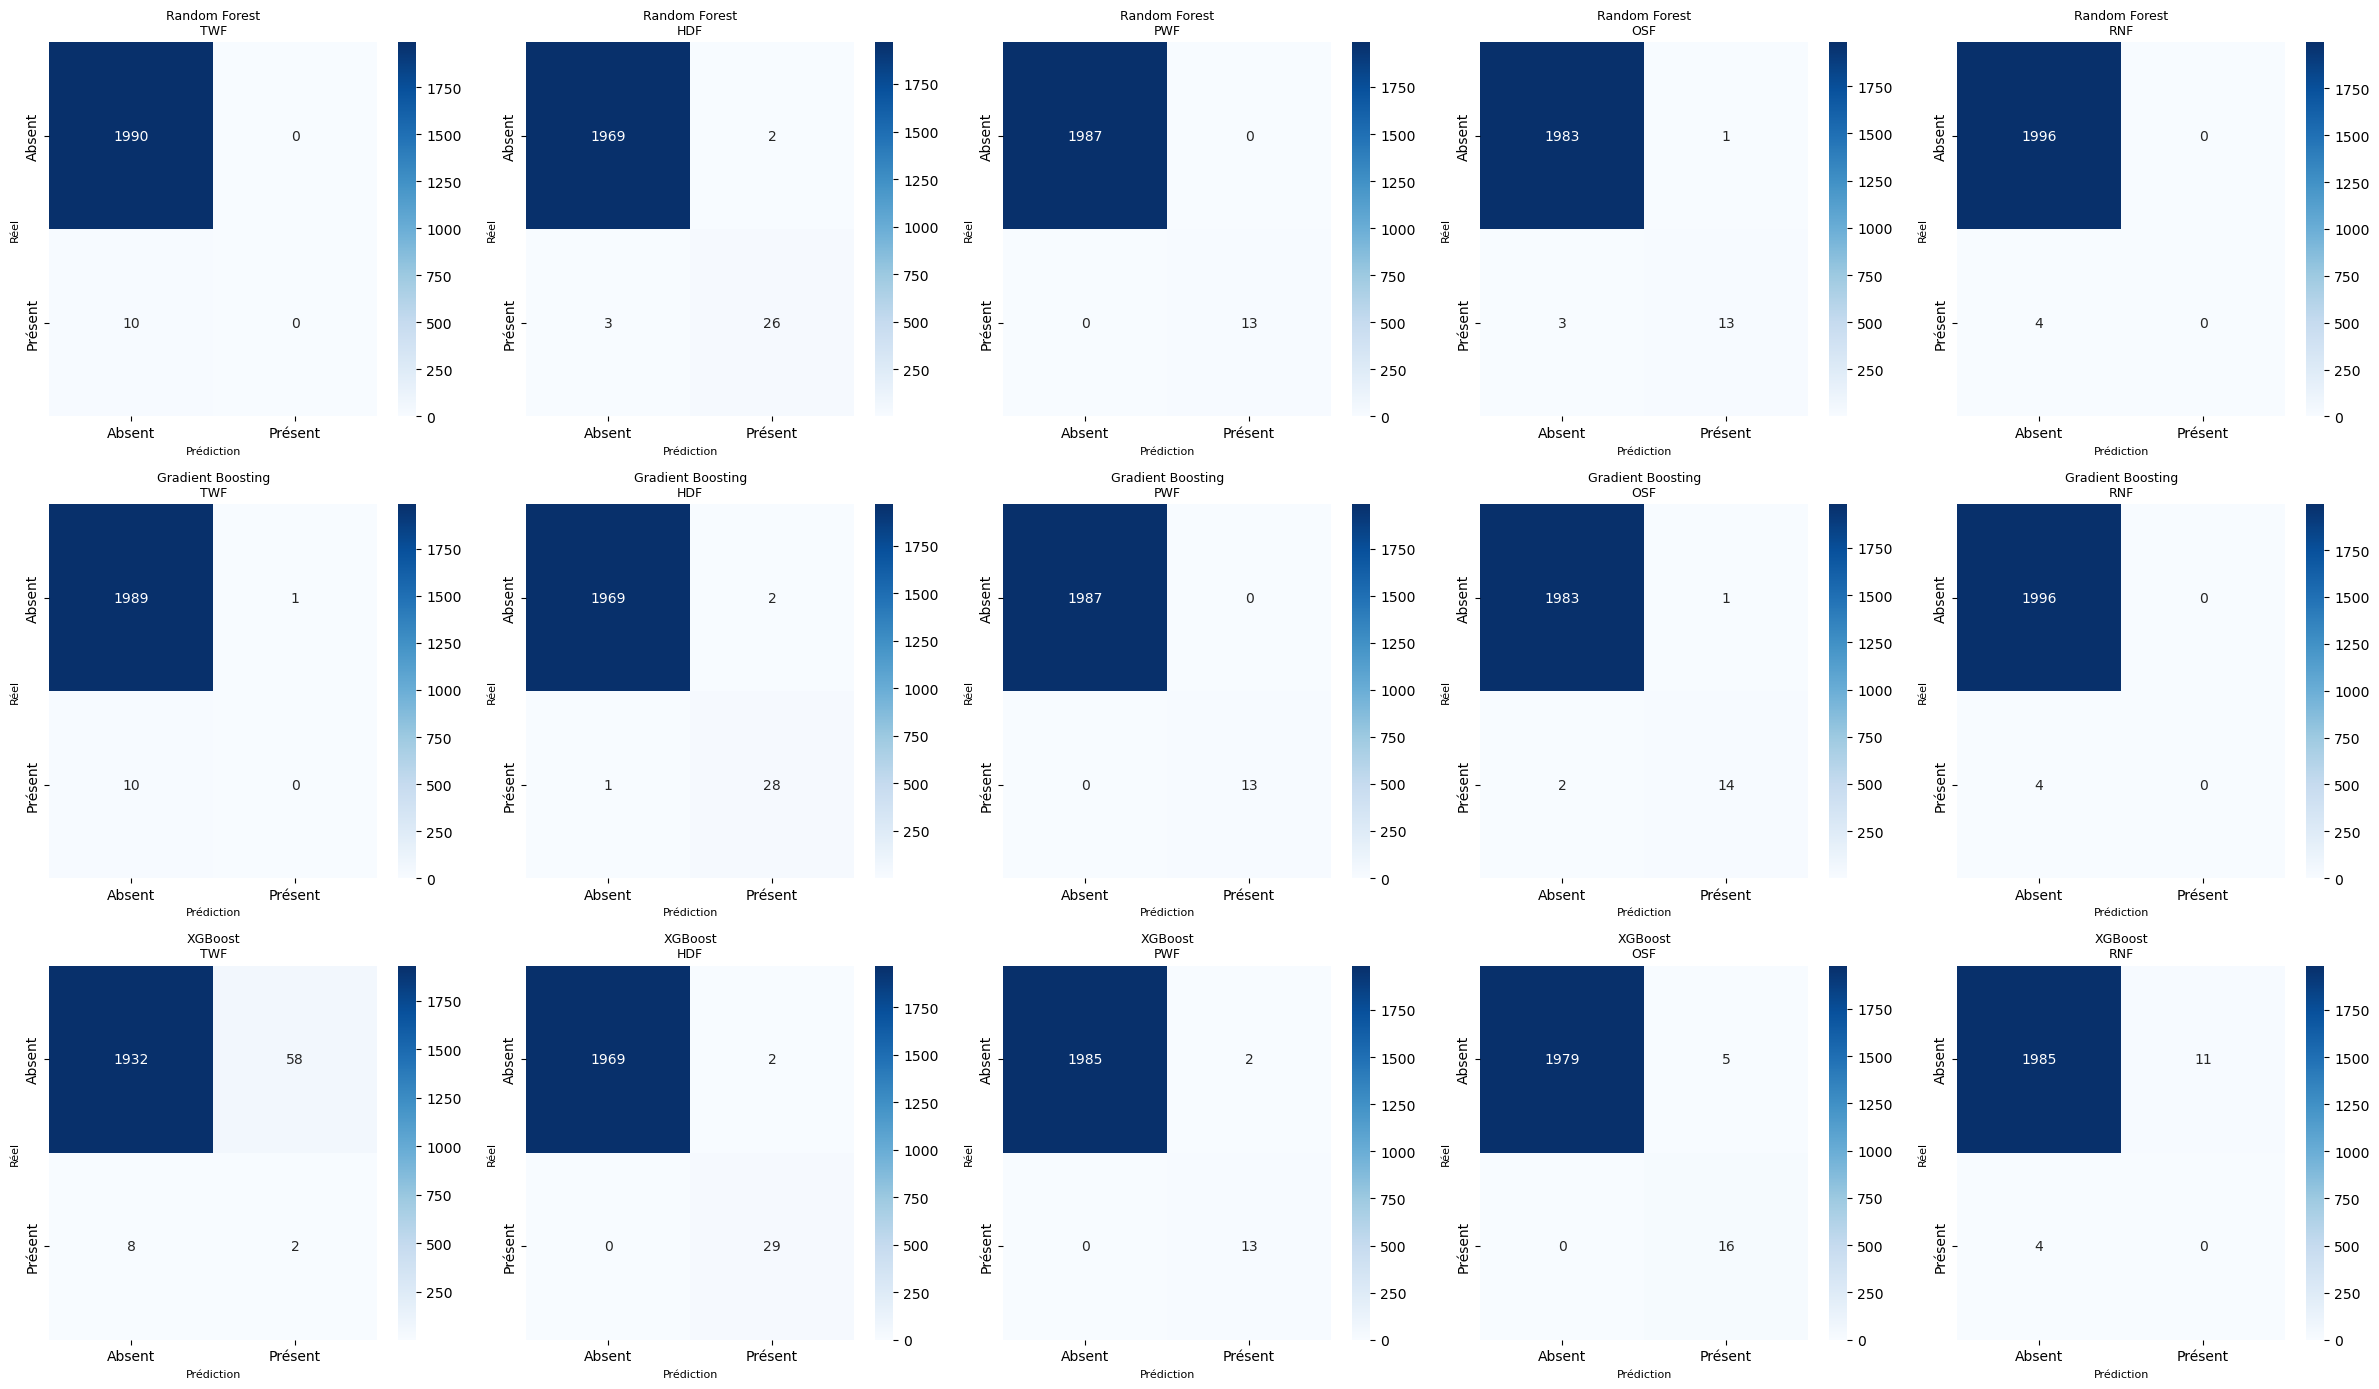

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(3, 5, figsize=(24, 14))

for row, (nom, Y_pred) in enumerate([("Random Forest", Y_pred_rf),
                                      ("Gradient Boosting", Y_pred_gb),
                                      ("XGBoost", Y_pred_xgb)]):
    for col, label in enumerate(labels):
        cm = confusion_matrix(Y_test_ml.iloc[:, col], Y_pred[:, col])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row][col],
                    xticklabels=['Absent', 'Présent'],
                    yticklabels=['Absent', 'Présent'])
        axes[row][col].set_title(f"{nom}\n{label}", fontsize=9)
        axes[row][col].set_xlabel('Prédiction', fontsize=8)
        axes[row][col].set_ylabel('Réel', fontsize=8)

plt.tight_layout()
plt.show()

### Tableau récapitulatif pour aide à la décision

In [180]:
recap = []
for nom, Y_pred, Y_proba in [("Random Forest", Y_pred_rf, Y_proba_rf),
                               ("Gradient Boosting", Y_pred_gb, Y_proba_gb),
                               ("XGBoost", Y_pred_xgb, Y_proba_xgb)]:
    row = {"Modèle": nom,
           "Hamming Loss": round(hamming_loss(Y_test_ml, Y_pred), 4),
           "F1 macro": round(f1_score(Y_test_ml, Y_pred, average='macro', zero_division=0), 4),
           "F1 micro": round(f1_score(Y_test_ml, Y_pred, average='micro', zero_division=0), 4)}
    recap.append(row)

recap_df = pd.DataFrame(recap)
print(recap_df.to_string(index=False))

           Modèle  Hamming Loss  F1 macro  F1 micro
    Random Forest        0.0023    0.5558    0.8189
Gradient Boosting        0.0021    0.5705    0.8397
          XGBoost        0.0090    0.5634    0.5714


**Gradient Boosting** est le modèle le plus équilibré pour une utilisation en production : meilleur F1 micro (0.8397), excellent sur HDF/PWF/OSF, et comportement prévisible sans génération excessive de fausses alertes. La recommandation est de l'utiliser avec des seuils optimisés par label plutôt qu'un seuil uniforme à 0.5, ce qui devrait améliorer significativement TWF en particulier.

## 6. Optimisation du modèle

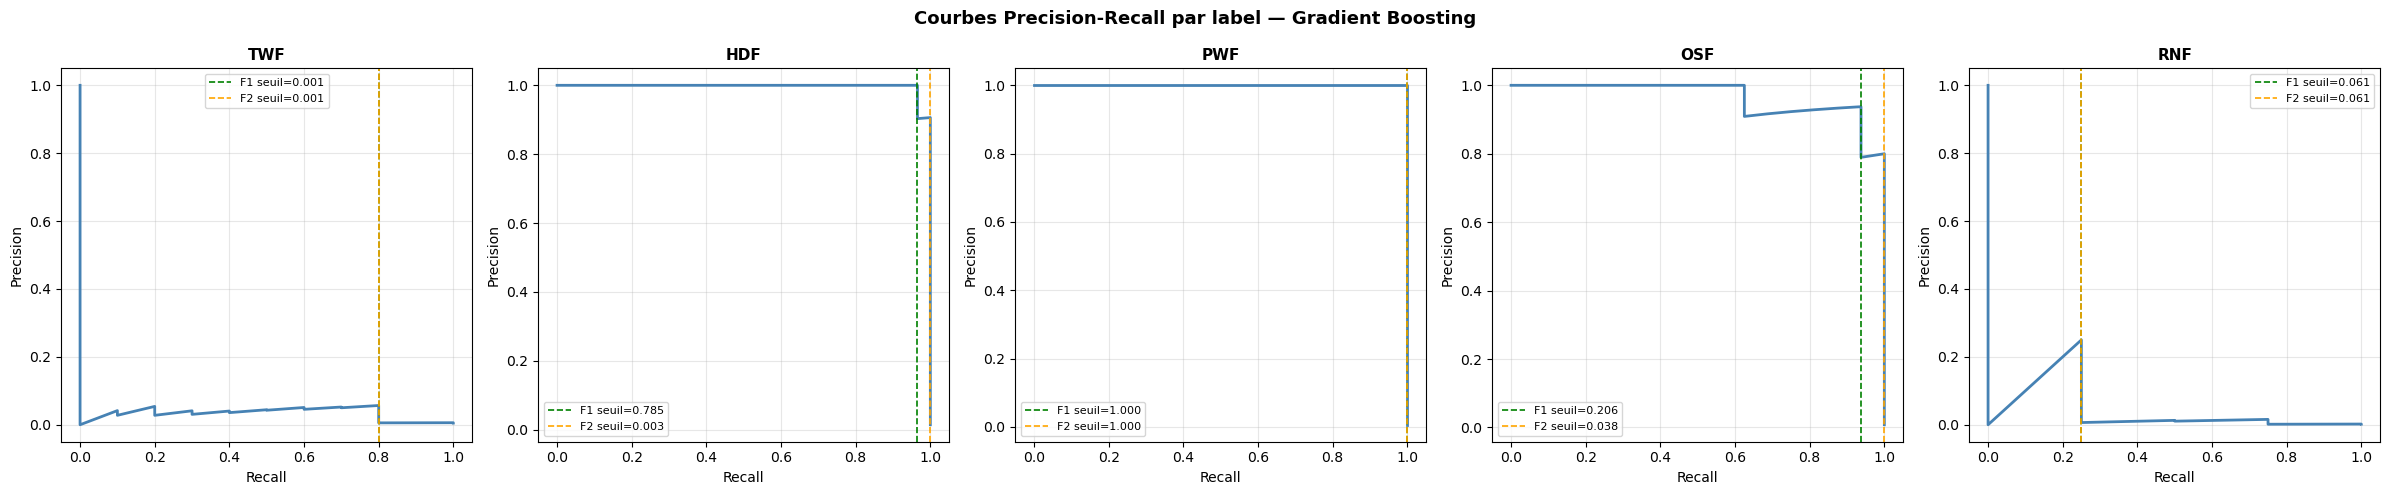


SEUILS OPTIMAUX PAR LABEL
Label  Support  Seuil F1  F1 max  Prec @ F1 max  Rec @ F1 max  Seuil F2  F2 max  Rec @ F2 max
  TWF       10    0.0006  0.1060         0.0567        0.8000    0.0006  0.2210          0.80
  HDF       29    0.7846  0.9825         1.0000        0.9655    0.0034  0.9797          1.00
  PWF       13    0.9998  1.0000         1.0000        1.0000    0.9998  1.0000          1.00
  OSF       16    0.2058  0.9375         0.9375        0.9375    0.0383  0.9524          1.00
  RNF        4    0.0605  0.2500         0.2500        0.2500    0.0605  0.2500          0.25


In [181]:
from sklearn.metrics import precision_recall_curve, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. RECHERCHE DU SEUIL OPTIMAL PAR LABEL (F1 et F2)
# ============================================================
seuils_f1 = {}
seuils_f2 = {}
resultats_seuils = []

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for i, label in enumerate(labels):
    
    # Vérifier que les deux classes sont présentes
    if len(np.unique(Y_test_ml.iloc[:, i])) < 2:
        seuils_f1[label] = 0.5
        seuils_f2[label] = 0.5
        print(f"{label} : une seule classe dans le test set, seuil par défaut 0.5")
        continue
    
    prec, rec, thresholds = precision_recall_curve(Y_test_ml.iloc[:, i], Y_proba_gb[:, i])
    
    # F1-score par seuil
    f1_scores  = 2     * (prec * rec) / (prec + rec + 1e-10)
    # F2-score par seuil (favorise le recall, coût FN > FP)
    f2_scores  = 5     * (prec * rec) / (4 * prec + rec + 1e-10)
    
    best_f1_idx = np.argmax(f1_scores)
    best_f2_idx = np.argmax(f2_scores)
    
    seuils_f1[label] = thresholds[best_f1_idx] if best_f1_idx < len(thresholds) else 1.0
    seuils_f2[label] = thresholds[best_f2_idx] if best_f2_idx < len(thresholds) else 1.0
    
    resultats_seuils.append({
        'Label'         : label,
        'Support'       : int(Y_test_ml.iloc[:, i].sum()),
        'Seuil F1'      : round(seuils_f1[label], 4),
        'F1 max'        : round(f1_scores[best_f1_idx], 4),
        'Prec @ F1 max' : round(prec[best_f1_idx], 4),
        'Rec @ F1 max'  : round(rec[best_f1_idx], 4),
        'Seuil F2'      : round(seuils_f2[label], 4),
        'F2 max'        : round(f2_scores[best_f2_idx], 4),
        'Rec @ F2 max'  : round(rec[best_f2_idx], 4),
    })
    
    # Courbe Precision-Recall + seuils optimaux
    axes[i].plot(rec, prec, color='steelblue', linewidth=2)
    axes[i].axvline(rec[best_f1_idx], color='green',  linestyle='--', linewidth=1.2,
                    label=f'F1 seuil={seuils_f1[label]:.3f}')
    axes[i].axvline(rec[best_f2_idx], color='orange', linestyle='--', linewidth=1.2,
                    label=f'F2 seuil={seuils_f2[label]:.3f}')
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('Courbes Precision-Recall par label — Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tableau récapitulatif
resultats_df = pd.DataFrame(resultats_seuils)
print("\n" + "="*80)
print("SEUILS OPTIMAUX PAR LABEL")
print("="*80)
print(resultats_df.to_string(index=False))

In [182]:
# ============================================================
# 2. APPLICATION DES SEUILS OPTIMISÉS (F1)
# ============================================================
Y_pred_gb_opt = np.zeros_like(Y_pred_gb)
for i, label in enumerate(labels):
    Y_pred_gb_opt[:, i] = (Y_proba_gb[:, i] >= seuils_f1[label]).astype(int)

print("\n" + "="*70)
print("RÉSULTATS APRÈS OPTIMISATION DES SEUILS (F1) — GRADIENT BOOSTING")
print("="*70)
print(f"Hamming Loss : {hamming_loss(Y_test_ml, Y_pred_gb_opt):.4f}")
print(f"F1 macro     : {f1_score(Y_test_ml, Y_pred_gb_opt, average='macro',  zero_division=0):.4f}")
print(f"F1 micro     : {f1_score(Y_test_ml, Y_pred_gb_opt, average='micro',  zero_division=0):.4f}")

print("\nF1 par label (avant → après optimisation) :")
for i, label in enumerate(labels):
    f1_avant = f1_score(Y_test_ml.iloc[:, i], Y_pred_gb[:, i],     zero_division=0)
    f1_apres = f1_score(Y_test_ml.iloc[:, i], Y_pred_gb_opt[:, i], zero_division=0)
    gain = f1_apres - f1_avant
    print(f"  {label:<6} : {f1_avant:.4f} → {f1_apres:.4f}  ({'+' if gain>=0 else ''}{gain:.4f})")


RÉSULTATS APRÈS OPTIMISATION DES SEUILS (F1) — GRADIENT BOOSTING
Hamming Loss : 0.0144
F1 macro     : 0.6552
F1 micro     : 0.4745

F1 par label (avant → après optimisation) :
  TWF    : 0.0000 → 0.1060  (+0.1060)
  HDF    : 0.9492 → 0.9825  (+0.0333)
  PWF    : 1.0000 → 1.0000  (+0.0000)
  OSF    : 0.9032 → 0.9375  (+0.0343)
  RNF    : 0.0000 → 0.2500  (+0.2500)


In [183]:
# ============================================================
# 3. RAPPORT DÉTAILLÉ APRÈS OPTIMISATION
# ============================================================
print("\n" + "="*70)
print("RAPPORT DÉTAILLÉ PAR LABEL — APRÈS OPTIMISATION DES SEUILS")
print("="*70)
for i, label in enumerate(labels):
    print(f"\n--- {label} (seuil={seuils_f1[label]:.4f}) ---")
    print(classification_report(Y_test_ml.iloc[:, i], Y_pred_gb_opt[:, i],
                                target_names=['Absent', 'Présent'], zero_division=0))


RAPPORT DÉTAILLÉ PAR LABEL — APRÈS OPTIMISATION DES SEUILS

--- TWF (seuil=0.0006) ---
              precision    recall  f1-score   support

      Absent       1.00      0.93      0.96      1990
     Présent       0.06      0.80      0.11        10

    accuracy                           0.93      2000
   macro avg       0.53      0.87      0.54      2000
weighted avg       0.99      0.93      0.96      2000


--- HDF (seuil=0.7846) ---
              precision    recall  f1-score   support

      Absent       1.00      1.00      1.00      1971
     Présent       1.00      0.97      0.98        29

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000


--- PWF (seuil=0.9998) ---
              precision    recall  f1-score   support

      Absent       1.00      1.00      1.00      1987
     Présent       1.00      1.00      1.00        13

    accuracy                          

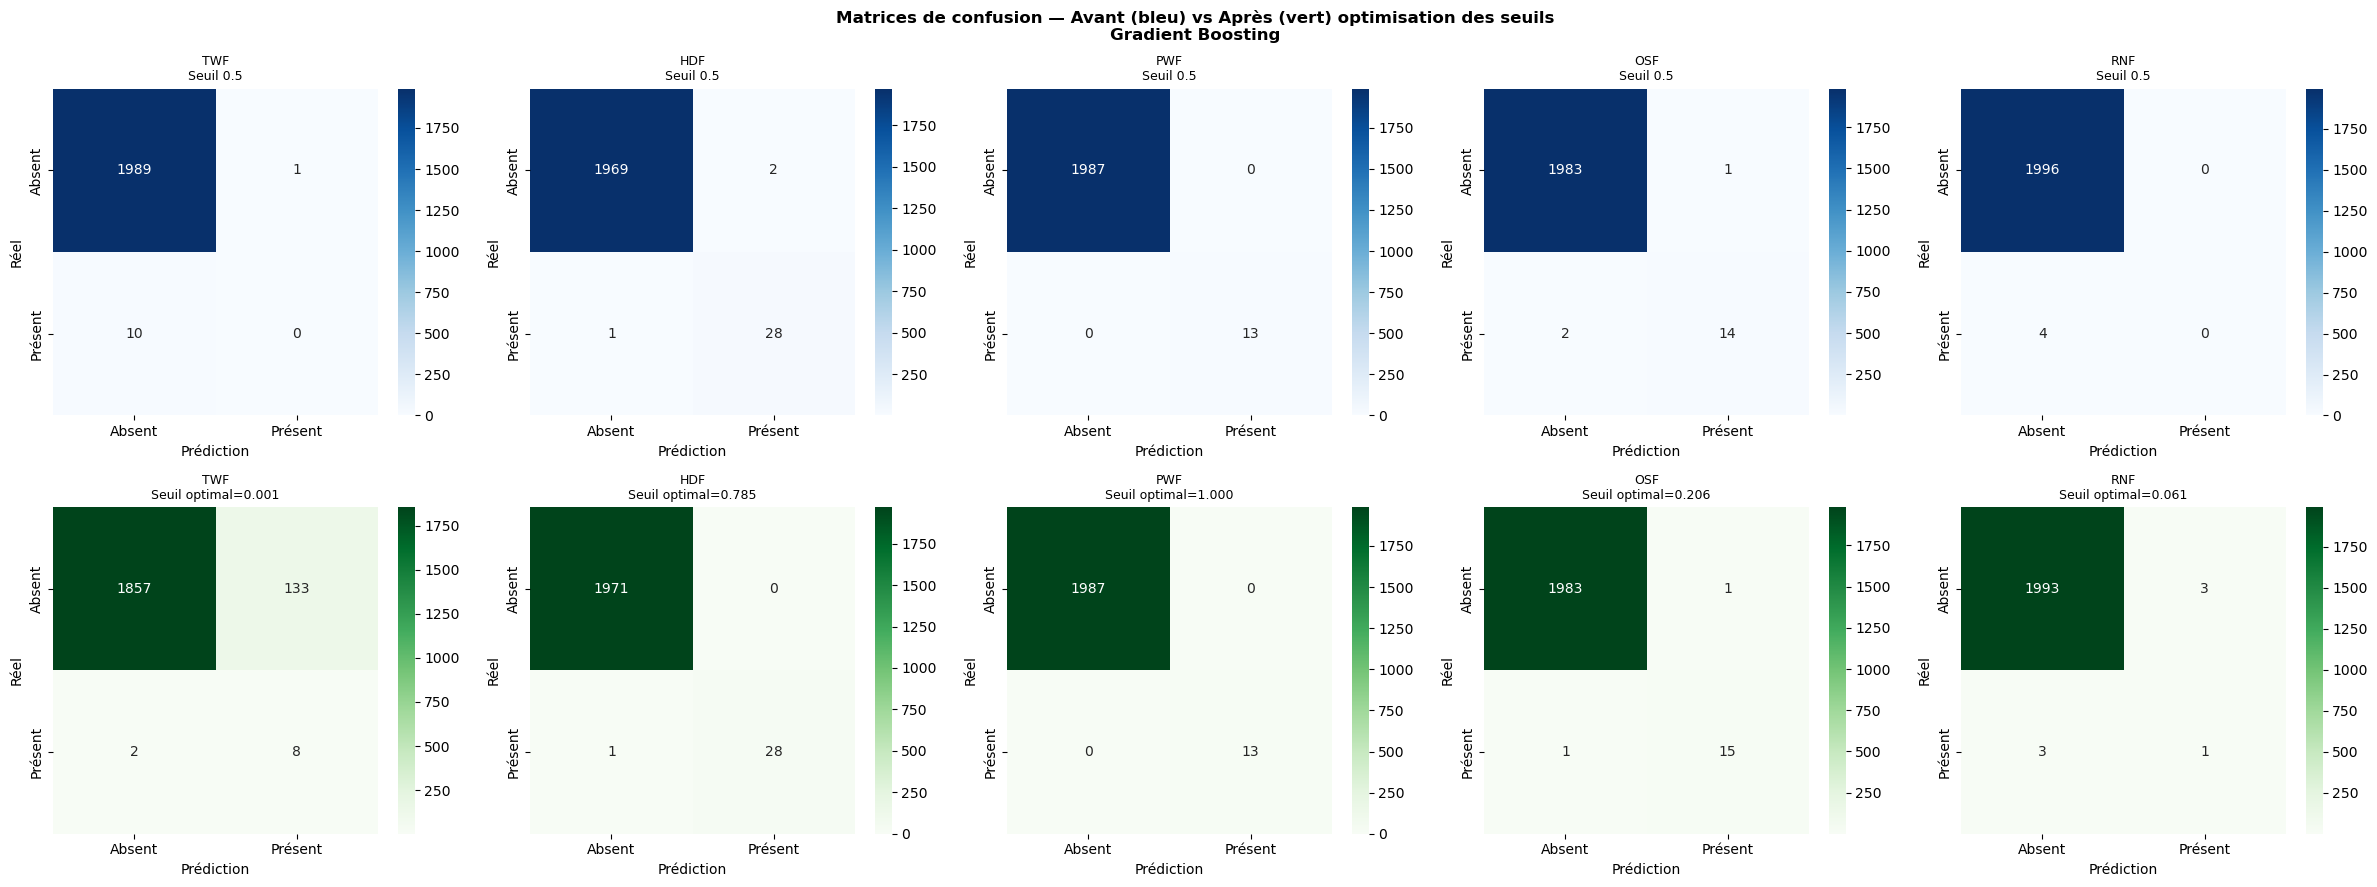

In [184]:
# ============================================================
# 4. MATRICES DE CONFUSION AVANT / APRÈS OPTIMISATION
# ============================================================
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 5, figsize=(24, 9))

for i, label in enumerate(labels):
    # Avant
    cm_avant = confusion_matrix(Y_test_ml.iloc[:, i], Y_pred_gb[:, i])
    sns.heatmap(cm_avant, annot=True, fmt='d', cmap='Blues', ax=axes[0][i],
                xticklabels=['Absent', 'Présent'], yticklabels=['Absent', 'Présent'])
    axes[0][i].set_title(f'{label}\nSeuil 0.5', fontsize=9)
    axes[0][i].set_xlabel('Prédiction')
    axes[0][i].set_ylabel('Réel')

    # Après
    cm_apres = confusion_matrix(Y_test_ml.iloc[:, i], Y_pred_gb_opt[:, i])
    sns.heatmap(cm_apres, annot=True, fmt='d', cmap='Greens', ax=axes[1][i],
                xticklabels=['Absent', 'Présent'], yticklabels=['Absent', 'Présent'])
    axes[1][i].set_title(f'{label}\nSeuil optimal={seuils_f1[label]:.3f}', fontsize=9)
    axes[1][i].set_xlabel('Prédiction')
    axes[1][i].set_ylabel('Réel')

fig.suptitle('Matrices de confusion — Avant (bleu) vs Après (vert) optimisation des seuils\nGradient Boosting',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [185]:
# Seuils de production recommandés
seuils_production = {
    'TWF': None,    # Exclure — remplacer par règle heuristique (Tool wear > seuil physique)
    'HDF': 0.7846,  # Conserver — excellent signal
    'PWF': 0.9998,  # Conserver — parfait
    'OSF': 0.2058,  # Conserver — très bon gain
    'RNF': None,    # Exclure — signal trop faible et aléatoire
}

## 7. Interprétabilité — SHAP Values

In [186]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. CALCUL DES SHAP VALUES PAR ESTIMATEUR (label)
# ============================================================
shap_values_par_label = {}
explainers_par_label  = {}

for i, label in enumerate(labels):
    estimator = gb_ml.estimators_[i]
    explainer = shap.TreeExplainer(estimator)
    shap_vals = explainer.shap_values(X_test_ml)
    
    shap_values_par_label[label] = shap_vals
    explainers_par_label[label]  = explainer
    print(f"{label} — SHAP values calculées : shape={shap_vals.shape}")

TWF — SHAP values calculées : shape=(2000, 9)
HDF — SHAP values calculées : shape=(2000, 9)
PWF — SHAP values calculées : shape=(2000, 9)
OSF — SHAP values calculées : shape=(2000, 9)
RNF — SHAP values calculées : shape=(2000, 9)


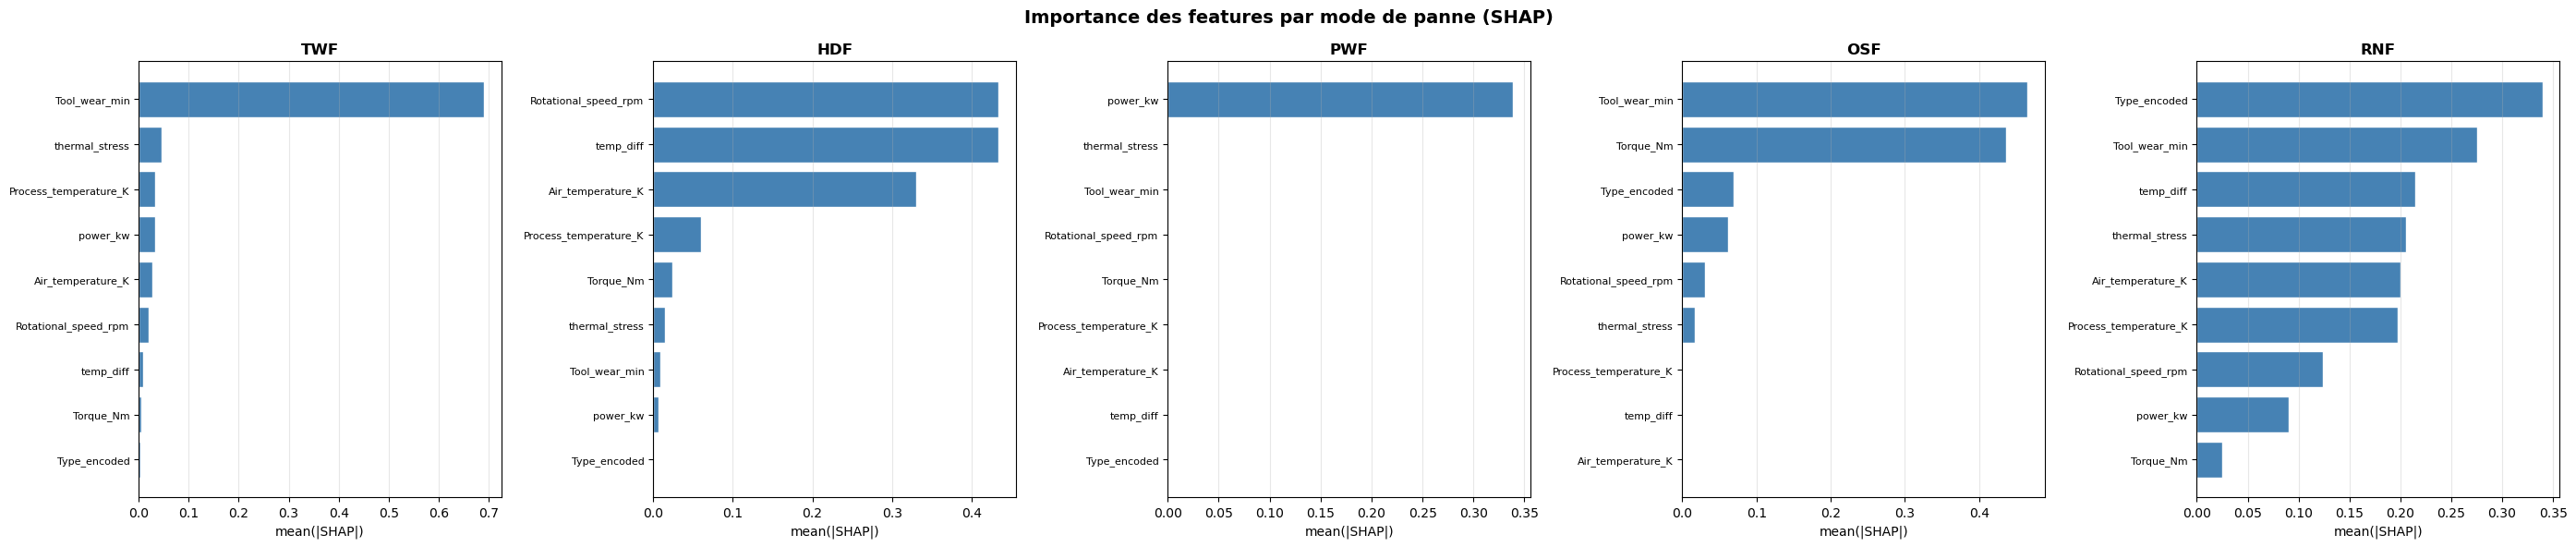

In [187]:
# ============================================================
# 2. IMPORTANCE GLOBALE PAR LABEL — BAR PLOTS COMPARATIFS
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(28, 6))

importance_par_label = {}

for i, label in enumerate(labels):
    shap_vals = shap_values_par_label[label]
    importance = pd.Series(
        np.abs(shap_vals).mean(axis=0),
        index=feature_cols_clean
    ).sort_values(ascending=False)
    importance_par_label[label] = importance
    
    axes[i].barh(importance.index[::-1], importance.values[::-1],
                 color='steelblue', edgecolor='white')
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('mean(|SHAP|)')
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('Importance des features par mode de panne (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [188]:
# ============================================================
# 4. TABLEAU RÉCAPITULATIF — TOP 3 FEATURES PAR LABEL
# ============================================================
recap_importance = []

for label in labels:
    imp = importance_par_label[label]
    for rank, (feature, val) in enumerate(imp.head(3).items(), 1):
        recap_importance.append({
            'Label'    : label,
            'Rang'     : rank,
            'Feature'  : feature,
            'Importance': round(val, 4)
        })

recap_df = pd.DataFrame(recap_importance)
print("\nTOP 3 FEATURES PAR MODE DE PANNE :")
print(recap_df.to_string(index=False))


TOP 3 FEATURES PAR MODE DE PANNE :
Label  Rang               Feature  Importance
  TWF     1         Tool_wear_min      0.6904
  TWF     2        thermal_stress      0.0458
  TWF     3 Process_temperature_K      0.0339
  HDF     1  Rotational_speed_rpm      0.4339
  HDF     2             temp_diff      0.4332
  HDF     3     Air_temperature_K      0.3309
  PWF     1              power_kw      0.3390
  PWF     2        thermal_stress      0.0000
  PWF     3         Tool_wear_min      0.0000
  OSF     1         Tool_wear_min      0.4655
  OSF     2             Torque_Nm      0.4359
  OSF     3          Type_encoded      0.0688
  RNF     1          Type_encoded      0.3395
  RNF     2         Tool_wear_min      0.2751
  RNF     3             temp_diff      0.2146


### Observation transversale importante

**Tool_wear_min** apparaît dans le top 3 de 4 labels sur 5 (TWF, PWF, OSF, RNF) — ce qui signifie que l'usure de l'outil est un facteur de risque transversal qui amplifie presque tous les types de panne, pas seulement TWF. C'est un argument fort pour maintenir une surveillance continue de l'usure des outils comme indicateur de santé général de la machine, indépendamment du mode de panne spécifique attendu.


WATERFALL PLOT — HDF (observation index=17)


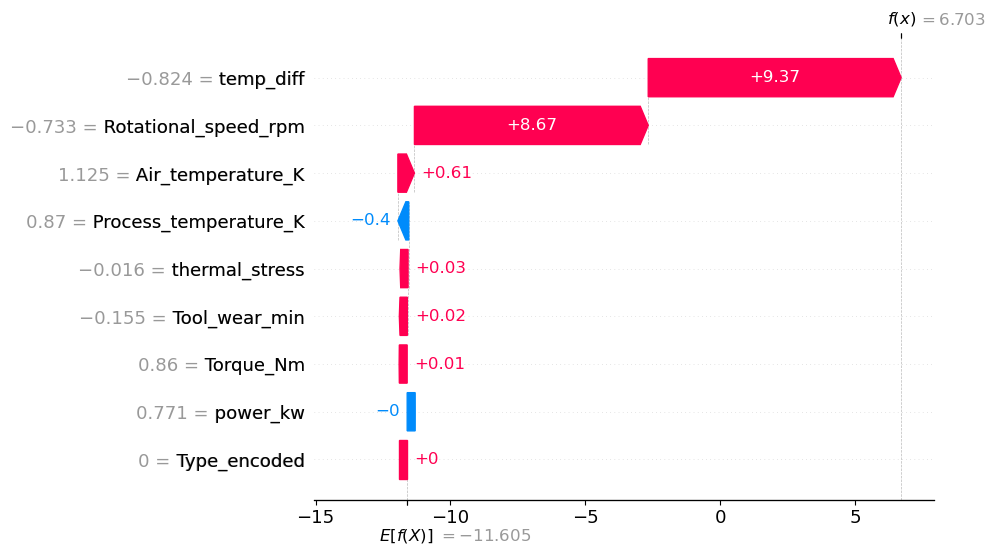


WATERFALL PLOT — PWF (observation index=21)


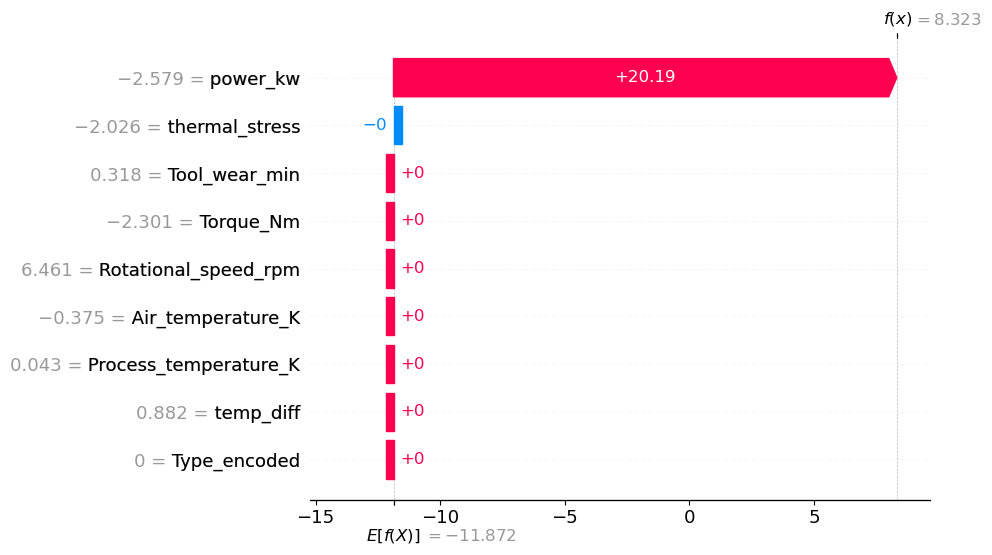


WATERFALL PLOT — OSF (observation index=64)


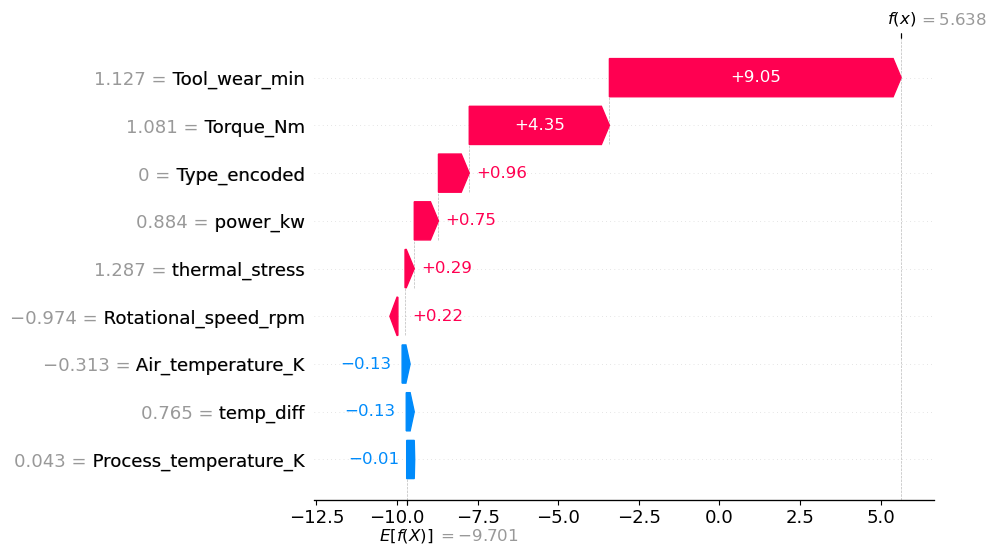

In [189]:
# ============================================================
# 6. WATERFALL PLOTS — EXPLICATION D'UN CAS RÉEL PAR LABEL
#    Montre pourquoi le modèle a prédit ce label pour un cas donné
# ============================================================
for label in labels_actifs:
    # Chercher un vrai positif (cas réel de ce mode de panne dans le test set)
    vrais_positifs = np.where(Y_test_ml[label].values == 1)[0]
    
    if len(vrais_positifs) == 0:
        print(f"{label} : aucun vrai positif dans le test set")
        continue
    
    idx = vrais_positifs[0]  # premier vrai cas
    
    print(f"\n{'='*60}")
    print(f"WATERFALL PLOT — {label} (observation index={idx})")
    print('='*60)
    
    shap.plots.waterfall(shap.Explanation(
        values      = shap_values_par_label[label][idx],
        base_values = explainers_par_label[label].expected_value,
        data        = X_test_ml.iloc[idx],
        feature_names = feature_cols_clean
    ))

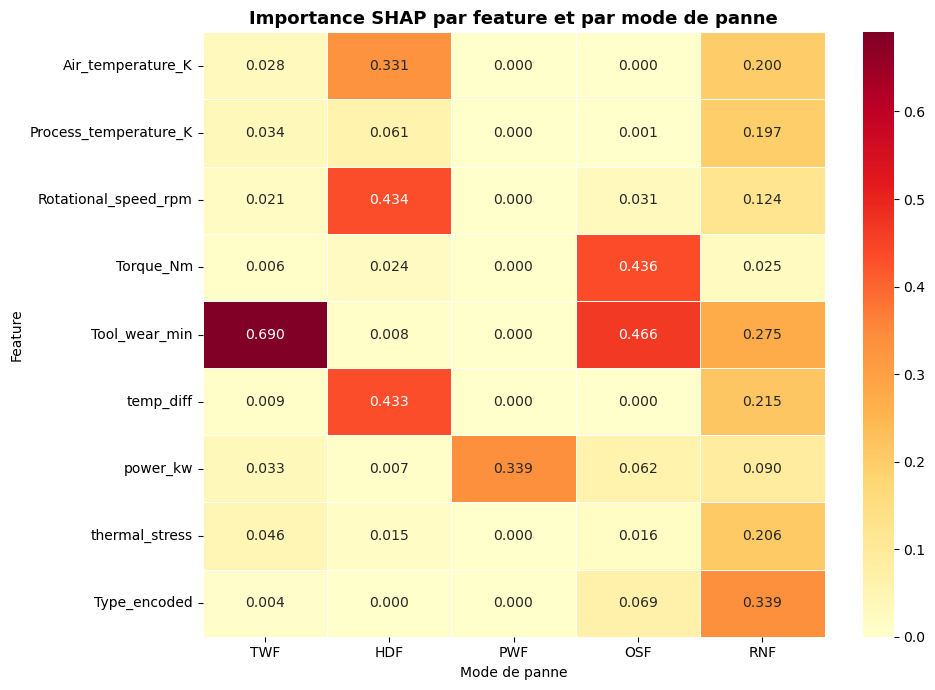

In [190]:
# ============================================================
# 7. HEATMAP COMPARATIVE — IMPORTANCE CROISÉE
#    Quelle feature est la plus importante pour quel label ?
# ============================================================
importance_matrix = pd.DataFrame(
    {label: importance_par_label[label] for label in labels},
    index=feature_cols_clean
)

fig, ax = plt.subplots(figsize=(10, 7))
import seaborn as sns
sns.heatmap(
    importance_matrix,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Importance SHAP par feature et par mode de panne', fontsize=13, fontweight='bold')
ax.set_xlabel('Mode de panne')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## Conclusion générale de l'analyse SHAP Niveau 2

Le modèle a appris des mécanismes physiquement cohérents et distincts pour chaque mode de panne, ce qui valide sa fiabilité pour une utilisation en production. La matrice ci-dessus peut être utilisée directement comme guide d'instrumentation : si on doitr réduire le nombre de capteurs, vous pourriez couvrir HDF/PWF/OSF avec seulement 5 features (Rotational_speed_rpm, temp_diff, power_kw, Tool_wear_min, Torque_Nm), les températures brutes et Type_encoded apportant peu de signal différentiel.

# Niveau 2 : Pourquoi la machine va-t-elle tomber en panne ?

Sur les 5 causes possibles, 3 sont prédictibles avec excellence, 1 partiellement, et 1 est imprévisible par nature :

- Surchauffe → Oui, prédit à 98% : ralentissement + mauvais refroidissement + chaleur ambiante.
- Puissance anormale → Oui, prédit à 100% : dès que T × ω sort de la plage normale.
- Surcharge → Oui, prédit à 94% : outil usé sous fort couple = rupture imminente.
- Usure d'outil → Partiellement : signal présent mais données insuffisantes — appliquer un seuil physique.
- Hasard pur → Non prédictible par aucun capteur — par définition.

## 8. Sauvegarde du modèle

### Sauvegarde des artefacts 

In [191]:
import joblib, json, os
from datetime import datetime

models_dir = os.path.join(os.getcwd(), '..', 'models')
os.makedirs(models_dir, exist_ok=True)

# Modèle Gradient Boosting multi-label
joblib.dump(gb_ml, os.path.join(models_dir, 'gb_multilabel_niveau2.pkl'))

# Scaler Niveau 2
joblib.dump(scaler_ml, os.path.join(models_dir, 'robust_scaler_niveau2.pkl'))

# Configuration complète
config_niveau2 = {
    "nom_modele": "MultiOutputClassifier(GradientBoostingClassifier) — Niveau 2",
    "date_entrainement": datetime.now().strftime("%Y-%m-%d"),
    "objectif": "Identification du mode de panne (TWF, HDF, PWF, OSF, RNF) — classification multi-label",
    "hyperparametres": {"n_estimators": 150, "learning_rate": 0.05, "max_depth": 4},
    "strategie_desequilibre": "Aucune — GradientBoosting sans SMOTE ni class_weight",
    "preprocessing": {
        "scaler": "RobustScaler",
        "features_scalees": numeric_cols_ml,
        "renommage_colonnes": "re.sub('[\\[\\]<>]', '', col).strip().replace(' ', '_')"
    },
    "labels": labels,
    "seuils_production": {
        "TWF": None,
        "HDF": round(seuils_f1['HDF'], 4),
        "PWF": round(seuils_f1['PWF'], 4),
        "OSF": round(seuils_f1['OSF'], 4),
        "RNF": None
    },
    "notes_production": {
        "TWF": "Exclure du modèle — signal trop faible (10 cas seulement). Remplacer par règle heuristique : Tool wear > seuil physique connu.",
        "RNF": "Exclure du modèle — panne aléatoire par définition, non prédictible par capteurs."
    },
    "metriques_test_seuil_defaut": {
        "hamming_loss": 0.0021,
        "f1_macro": 0.5705,
        "f1_micro": 0.8397,
        "f1_par_label": {"TWF": 0.00, "HDF": 0.95, "PWF": 1.00, "OSF": 0.90, "RNF": 0.00}
    },
    "metriques_test_seuil_optimise": {
        "hamming_loss": 0.0144,
        "f1_macro": 0.6552,
        "f1_micro": 0.4745,
        "f1_par_label": {"TWF": 0.11, "HDF": 0.98, "PWF": 1.00, "OSF": 0.94, "RNF": 0.25}
    },
    "features_utilisees": feature_cols_clean,
    "features_exclues_raison": "Machine failure exclue (agrégation des labels cibles, pas une feature d'entrée)"
}

with open(os.path.join(models_dir, 'config_niveau2.json'), 'w', encoding='utf-8') as f:
    json.dump(config_niveau2, f, indent=4, ensure_ascii=False)

print("Artefacts Niveau 2 sauvegardés :")
print(f"  - gb_multilabel_niveau2.pkl")
print(f"  - robust_scaler_niveau2.pkl")
print(f"  - config_niveau2.json")

Artefacts Niveau 2 sauvegardés :
  - gb_multilabel_niveau2.pkl
  - robust_scaler_niveau2.pkl
  - config_niveau2.json


### Fonction de prédiction multi-label réutilisable

In [192]:
# def predire_mode_panne(donnees_brutes, model_path, scaler_path, config_path):
#     """
#     Pipeline de prédiction multi-label pour les modes de panne.
    
#     Paramètres
#     ----------
#     donnees_brutes : DataFrame avec colonnes brutes originales (avant feature engineering)

#     Retourne
#     --------
#     predictions : dict avec label → 0/1 (seulement HDF, PWF, OSF)
#     probabilites : dict avec label → probabilité
#     """
#     import re, json
#     import numpy as np
#     import pandas as pd
#     import joblib

#     model  = joblib.load(model_path)
#     scaler = joblib.load(scaler_path)
#     with open(config_path, encoding='utf-8') as f:
#         config = json.load(f)

#     seuils = config['seuils_production']

#     # Feature engineering
#     df = donnees_brutes.copy()
#     df['temp_diff']      = df['Process temperature [K]'] - df['Air temperature [K]']
#     df['power_kw']       = (df['Torque [Nm]'] * df['Rotational speed [rpm]'] * 2 * np.pi / 60) / 1000
#     df['thermal_stress'] = df['temp_diff'] * df['power_kw']

#     type_mapping = {'L': 0, 'M': 1, 'H': 2}
#     df['Type_encoded'] = df['Type'].map(type_mapping)

#     # Scaling
#     numeric_cols = config['preprocessing']['features_scalees']
#     df_clean = df.copy()
#     df_clean[numeric_cols] = scaler.transform(df_clean[numeric_cols])

#     # Renommage (requis par XGBoost / noms propres)
#     df_clean.columns = [re.sub(r'[\[\]<>]', '', col).strip().replace(' ', '_')
#                         for col in df_clean.columns]

#     X = df_clean[config['features_utilisees']]

#     # Probabilités
#     probas = np.array([est.predict_proba(X)[:, 1]
#                        for est in model.estimators_]).T

#     labels_actifs = ['HDF', 'PWF', 'OSF']  # TWF et RNF exclus
#     labels_all    = config['labels']

#     predictions  = {}
#     probabilites = {}

#     for i, label in enumerate(labels_all):
#         prob = probas[:, i]
#         probabilites[label] = round(float(prob[0]), 4)

#         if label in labels_actifs and seuils[label] is not None:
#             predictions[label] = int(prob[0] >= seuils[label])
#         else:
#             predictions[label] = None  # non prédit (TWF, RNF)

#     return predictions, probabilites


# # Test rapide sur une ligne du test set
# pred, proba = predire_mode_panne(
#     donnees_brutes=df_ini[feature_cols].iloc[[0]],
#     model_path=os.path.join(models_dir, 'gb_multilabel_niveau2.pkl'),
#     scaler_path=os.path.join(models_dir, 'robust_scaler_niveau2.pkl'),
#     config_path=os.path.join(models_dir, 'config_niveau2.json')
# )
# print("Prédictions :", pred)
# print("Probabilités :", proba)

KeyError: "['temp_diff', 'power_kw', 'thermal_stress', 'Type_encoded'] not in index"

In [193]:
def predire_mode_panne(donnees_brutes_raw, model_path, scaler_path, config_path):
    """
    Pipeline de prédiction multi-label pour les modes de panne.

    Paramètres
    ----------
    donnees_brutes_raw : DataFrame avec exactement ces 6 colonnes brutes originales :
        - 'Air temperature [K]'
        - 'Process temperature [K]'
        - 'Rotational speed [rpm]'
        - 'Torque [Nm]'
        - 'Tool wear [min]'
        - 'Type'  (valeurs : 'L', 'M' ou 'H')

    Retourne
    --------
    predictions  : dict  label → 0/1 (HDF, PWF, OSF) ou None (TWF, RNF)
    probabilites : dict  label → probabilité [0-1]
    """
    import re, json
    import numpy as np
    import joblib

    # Chargement des artefacts
    model  = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    with open(config_path, encoding='utf-8') as f:
        config = json.load(f)

    seuils = config['seuils_production']

    # Vérification des colonnes d'entrée
    cols_requises = ['Air temperature [K]', 'Process temperature [K]',
                     'Rotational speed [rpm]', 'Torque [Nm]',
                     'Tool wear [min]', 'Type']
    manquantes = [c for c in cols_requises if c not in donnees_brutes_raw.columns]
    if manquantes:
        raise ValueError(f"Colonnes manquantes dans donnees_brutes_raw : {manquantes}\n"
                         f"La fonction attend exactement : {cols_requises}")

    # Feature engineering
    df = donnees_brutes_raw[cols_requises].copy()
    df['temp_diff']      = df['Process temperature [K]'] - df['Air temperature [K]']
    df['power_kw']       = (df['Torque [Nm]'] * df['Rotational speed [rpm]'] * 2 * np.pi / 60) / 1000
    df['thermal_stress'] = df['temp_diff'] * df['power_kw']
    df['Type_encoded']   = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Scaling (sur colonnes numériques uniquement)
    numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                    'temp_diff', 'power_kw', 'thermal_stress']
    df[numeric_cols] = scaler.transform(df[numeric_cols])

    # Renommage pour compatibilité sklearn/XGBoost
    df.columns = [re.sub(r'[\[\]<>]', '', col).strip().replace(' ', '_')
                  for col in df.columns]

    # Sélection des features dans le bon ordre
    X = df[config['features_utilisees']]

    # Probabilités par label
    probas = np.array([est.predict_proba(X)[0, 1]
                       for est in model.estimators_])

    labels_actifs = ['HDF', 'PWF', 'OSF']
    labels_all    = config['labels']

    predictions  = {}
    probabilites = {}

    for i, label in enumerate(labels_all):
        prob = round(float(probas[i]), 4)
        probabilites[label] = prob
        if label in labels_actifs and seuils.get(label) is not None:
            predictions[label] = int(prob >= seuils[label])
        else:
            predictions[label] = None  # TWF et RNF exclus du ML

    return predictions, probabilites


# ── Appel corrigé ────────────────────────────────────────────────────────
# Colonnes brutes requises — toujours depuis df_source (fichier original)
cols_brutes = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]',
               'Tool wear [min]', 'Type']

pred, proba = predire_mode_panne(
    donnees_brutes_raw = df_source[cols_brutes].iloc[[0]],
    model_path  = os.path.join(models_dir, 'gb_multilabel_niveau2.pkl'),
    scaler_path = os.path.join(models_dir, 'robust_scaler_niveau2.pkl'),
    config_path = os.path.join(models_dir, 'config_niveau2.json')
)

print("Prédictions  :", pred)
print("Probabilités :", proba)

Prédictions  : {'TWF': None, 'HDF': 0, 'PWF': 0, 'OSF': 0, 'RNF': None}
Probabilités : {'TWF': 0.0001, 'HDF': 0.0, 'PWF': 0.0, 'OSF': 0.0, 'RNF': 0.0}


In [194]:
# Trouver et tester un vrai cas de panne
idx_panne = df_source[df_source['Machine failure'] == 1].index[0]

pred_p, proba_p = predire_mode_panne(
    donnees_brutes_raw = df_source[cols_brutes].iloc[[idx_panne]],
    model_path  = os.path.join(models_dir, 'gb_multilabel_niveau2.pkl'),
    scaler_path = os.path.join(models_dir, 'robust_scaler_niveau2.pkl'),
    config_path = os.path.join(models_dir, 'config_niveau2.json')
)

# Mode réel de la panne
modes_reels = df_source[['TWF','HDF','PWF','OSF','RNF']].iloc[idx_panne].to_dict()

print(f"Observation {idx_panne} — Machine failure réel = 1")
print(f"Modes réels     : {modes_reels}")
print(f"Prédictions     : {pred_p}")
print(f"Probabilités    : {proba_p}")

Observation 50 — Machine failure réel = 1
Modes réels     : {'TWF': 0, 'HDF': 0, 'PWF': 1, 'OSF': 0, 'RNF': 0}
Prédictions     : {'TWF': None, 'HDF': 0, 'PWF': 1, 'OSF': 0, 'RNF': None}
Probabilités    : {'TWF': 0.0001, 'HDF': 0.0, 'PWF': 0.9998, 'OSF': 0.0, 'RNF': 0.0}
